Scatter Plot - This type of plot is great to show correlation between multiple variables 

In [ ]:
#importing Libraries 
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

c:\Users\vshru\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#loading data
dataset = load_dataset('lukebarousse/data_jobs')
df =dataset['train'].to_pandas()

In [3]:
#Cleanup data
df['job_posted_date']= pd.to_datetime(df['job_posted_date'])

In [4]:
df['job_skills'] = df['job_skills'].apply(lambda x:ast.literal_eval(x) if pd.notna(x)else x)

In [ ]:
#This  is a filtering operation. It is used to narrow down your entire dataset so that it only includes rows related to Data Analysts.
df=df[df['job_title_short']=='Data Analyst']

In [ ]:
df

In [7]:
#Turns list into its own row 
df_exploded_skills=df.explode('job_skills')

In [ ]:
df_exploded_skills

In [9]:
#count of job skills 
skill_stats=df_exploded_skills.groupby('job_skills').agg(
    skill_count = ('job_skills','count'),
    median_salary = ('salary_year_avg','median')
)

In [10]:
skill_stats=skill_stats.sort_values(by ='skill_count',ascending = False).head(10)

In [11]:
skill_stats

,skill_count,median_salary
job_skills,,
sql,92428,92500.0
excel,66860,84479.0
python,57190,98500.0
tableau,46455,95000.0
power bi,39380,90000.0
r,29996,92527.5
sas,27998,90000.0
powerpoint,13822,85000.0
word,13562,80000.0


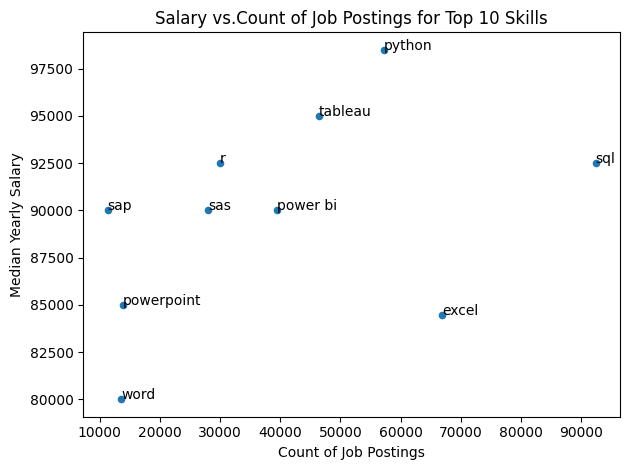

In [14]:
skill_stats.plot(kind = 'scatter',x ='skill_count' ,y ='median_salary')
plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary')
plt.title('Salary vs.Count of Job Postings for Top 10 Skills')


for i,txt in enumerate(skill_stats.index):
    plt.text(skill_stats['skill_count'].iloc[i],skill_stats['median_salary'].iloc[i],txt)


plt.tight_layout()
plt.show()